In [64]:
import numpy as np
import pylab as plt
import networkx as nx
import pandas as pd
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
import os

In [4]:
# Torus module imports
from modules import graphio
from modules import visualization as vis
from modules.projector import MDSTorusProjector

In [67]:
res_path = os.path.join(os.path.expanduser("~/data/graph_torus/figures"))

## Lattice graph

In [ ]:
G,D = graphio.get_periodic_lattice(20,20)

#Normalize or don't
# D /= np.max(D)

proj_torus = MDSTorusProjector()
X_torus = proj_torus.fit_transform(D)

fig, ax = plt.subplots()

vis.plot_embedding_with_torus_edges(X_torus, G, ax=ax)

In [5]:
G40, D40 = graphio.get_periodic_lattice(20, 40)

[alpha]  alpha=25.13
[square]  r=39.08
[rectangular]  r0=39.23  r1=38.89  ratio=0.991


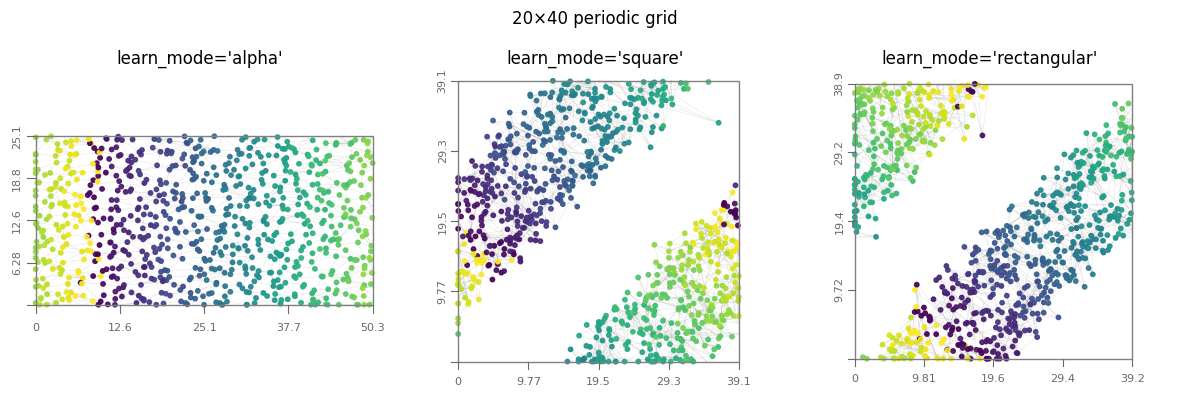

In [8]:
colors = [j for (i, j) in G40.nodes()]
colors_short = [i for (i, j) in G40.nodes()]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    proj.fit_transform(D40,
                       learn_mode=mode,
                       r0_init=2.0,
                       r1_init=1.0,)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_ / proj.r0_:.3f}")
    vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=ax, colors=colors)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×40 periodic grid")
plt.tight_layout()

In [9]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh


def lowest_laplacian_eigenvalues(
    D,
    k=15,
    sigma=None,
    n_eigs=6,
    normalized=True,
):
    """
    Compute the lowest eigenvalues of a symmetrized graph Laplacian
    from a pairwise distance matrix.

    Parameters
    ----------
    D : (n, n) array
        Pairwise distance matrix.
    k : int
        Number of nearest neighbors per point.
    sigma : float or None
        Gaussian kernel bandwidth. If None, uses median kNN distance.
    n_eigs : int
        Number of lowest eigenvalues to compute.
    normalized : bool
        If True, use symmetric normalized Laplacian:
            L = I - D^{-1/2} W D^{-1/2}
        If False, use unnormalized Laplacian:
            L = D - W

    Returns
    -------
    evals : (n_eigs,) array
        Lowest eigenvalues.
    evecs : (n, n_eigs) array
        Corresponding eigenvectors.
    """

    D = np.asarray(D)
    n = D.shape[0]

    if D.shape != (n, n):
        raise ValueError("D must be a square distance matrix.")

    if sigma is None:
        k = min(k, n-1)
        knn_dists = np.partition(D, kth=k, axis=1)[:, 1:k + 1]
        sigma = np.median(knn_dists)

    # kNN indices, excluding self
    nn_idx = np.argpartition(D, kth=k, axis=1)[:, 1:k + 1]

    rows = np.repeat(np.arange(n), k)
    cols = nn_idx.ravel()
    vals = np.exp(-(D[rows, cols] ** 2) / (2 * sigma**2))

    W = csr_matrix((vals, (rows, cols)), shape=(n, n))

    # Symmetrize graph, but D should already be symmetric
    W = W.maximum(W.T)

    degrees = np.asarray(W.sum(axis=1)).ravel()

    if normalized:
        inv_sqrt_deg = np.zeros_like(degrees)
        mask = degrees > 0
        inv_sqrt_deg[mask] = 1.0 / np.sqrt(degrees[mask])

        D_inv_sqrt = diags(inv_sqrt_deg)
        L = diags(np.ones(n)) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        L = diags(degrees) - W

    evals, evecs = eigsh(L, k=n_eigs, which="SM")

    order = np.argsort(evals)
    return evals[order], evecs[:, order]

In [109]:
# ── helpers: phase extraction, harmonic scoring, initialisation ──────────────

def _phase_from_pair(evec_pair, eps=1e-12):
    """
    Convert a 2D eigenvector pair into circular phases.

    Parameters
    ----------
    evec_pair : (n, 2) array

    Returns
    -------
    z : (n,) complex array
        Unit-modulus complex phase representation.
    theta : (n,) array
        Angles in [-pi, pi].
    """
    u = evec_pair[:, 0]
    v = evec_pair[:, 1]

    u = u - np.mean(u)
    v = v - np.mean(v)

    z = u + 1j * v
    z = z / np.maximum(np.abs(z), eps)

    theta = np.angle(z)
    return z, theta


def torus_init_from_eigenpairs(pair1, pair2):
    _, theta1 = _phase_from_pair(pair1)
    _, theta2 = _phase_from_pair(pair2)

    x = np.mod(theta1, 2 * np.pi) / (2 * np.pi)
    y = np.mod(theta2, 2 * np.pi) / (2 * np.pi)

    return np.column_stack([x, y])


def harmonic_score(z_candidate, z_reference, m):
    """
    Score whether candidate phase is approximately an m-th harmonic
    of the reference phase.  Score is in [0, 1].
    """
    score_pos = np.abs(np.mean(z_candidate * np.conj(z_reference ** m)))
    score_neg = np.abs(np.mean(z_candidate * (z_reference ** m)))
    return max(score_pos, score_neg)


# ── helpers for degenerate eigenspaces ───────────────────────────────────────

def _group_eigenvectors(evals, evecs, degenerate_tol=0.2):
    """
    Partition consecutive eigenvectors into groups of size 2 or 4.

    Two consecutive size-2 pairs are merged into a 4-group when their mean
    eigenvalues differ by less than degenerate_tol (relative).  This detects
    the two cases where the standard pair-wise approach breaks:

      * aspect_ratio ≈ integer  — the k-th harmonic of direction 0 and the
        independent direction 1 land at the same eigenvalue.
      * aspect_ratio ≈ 1        — both fundamental directions share the first
        non-zero eigenspace.

    Returns a list of dicts with keys: size, eigenvalues, eigenvectors, lambda_mean.
    """
    groups = []
    j = 0
    n = len(evals)
    while j + 1 < n:
        lam_a = float(np.mean(evals[j:j + 2]))
        if j + 4 <= n:
            lam_b = float(np.mean(evals[j + 2:j + 4]))
            if abs(lam_b - lam_a) / max(lam_a, 1e-12) < degenerate_tol:
                groups.append({
                    "size": 4,
                    "eigenvalues": evals[j:j + 4],
                    "eigenvectors": evecs[:, j:j + 4],
                    "lambda_mean": float(np.mean(evals[j:j + 4])),
                })
                j += 4
                continue
        groups.append({
            "size": 2,
            "eigenvalues": evals[j:j + 2],
            "eigenvectors": evecs[:, j:j + 2],
            "lambda_mean": lam_a,
        })
        j += 2
    return groups


def _split_by_harmonic_projection(V, z_ref, m):
    """
    Split 4D subspace V into harmonic and independent components.

    Uses z_ref^m as a fingerprint for the m-th harmonic: projects its real
    and imaginary parts onto V, giving a (4, 2) coefficient matrix C.  The
    SVD of C identifies the 2D sub-direction in V that best represents the
    harmonic; the orthogonal complement is the independent direction.

    Parameters
    ----------
    V     : (N, 4) orthonormal basis of a degenerate eigenspace
    z_ref : (N,) complex, unit-modulus reference direction
    m     : int, harmonic order

    Returns
    -------
    harmonic_basis    : (N, 2)
    independent_basis : (N, 2)
    score             : float in [0, 1]
        Fraction of ||z_ref^m|| captured by V.  Near 1 means the harmonic
        truly lives in this 4D subspace.
    """
    h = z_ref ** m
    h_re = np.real(h)
    h_im = np.imag(h)

    C = np.column_stack([V.T @ h_re, V.T @ h_im])  # (4, 2)
    U, s, _ = np.linalg.svd(C, full_matrices=True)

    h_norm = np.sqrt(np.dot(h_re, h_re) + np.dot(h_im, h_im))
    score = float(np.sqrt(s[0] ** 2 + s[1] ** 2) / max(h_norm, 1e-12))

    return V @ U[:, :2], V @ U[:, 2:], score


def _split_by_flatness(V, n_starts=10, seed=0):
    """
    Find the 2+2 split of 4D subspace V minimising Var(|z1|^2) + Var(|z2|^2),
    where |z|^2 = u^2 + v^2 for a pair (u, v).

    For a correct torus pair {cos(ωx), sin(ωx)}, |z|^2 = 1 everywhere (flat).
    For a mixed pair the modulus varies, yielding a higher objective.  Used when
    no prior reference direction exists (aspect_ratio ≈ 1 case).

    Optimises over O(4) via the matrix exponential of a skew-symmetric matrix
    (6 free parameters).  Uses n_starts random initialisations.

    Returns
    -------
    pair1 : (N, 2)
    pair2 : (N, 2)
    """
    from scipy.linalg import expm
    from scipy.optimize import minimize

    rng = np.random.default_rng(seed)

    def _skew(a):
        return np.array([
            [ 0,   -a[0], -a[1], -a[2]],
            [a[0],  0,    -a[3], -a[4]],
            [a[1],  a[3],  0,    -a[5]],
            [a[2],  a[4],  a[5],  0   ],
        ])

    def objective(angles):
        B = V @ expm(_skew(angles))
        return float(np.var(B[:, 0] ** 2 + B[:, 1] ** 2)
                     + np.var(B[:, 2] ** 2 + B[:, 3] ** 2))

    best_val, best_angles = np.inf, np.zeros(6)
    for _ in range(n_starts):
        x0 = rng.standard_normal(6) * 0.3
        res = minimize(objective, x0, method='L-BFGS-B')
        if res.fun < best_val:
            best_val, best_angles = res.fun, res.x

    B = V @ expm(_skew(best_angles))
    return B[:, :2], B[:, 2:]


# ── main function ─────────────────────────────────────────────────────────────

def find_fundamental_torus_directions(
    D,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=20,
    zero_tol=1e-8,
    harmonic_threshold=0.75,
    max_harmonic=8,
    degenerate_tol=0.2,
):
    """
    Find the first two independent torus directions from graph Laplacian
    eigenvectors, skipping harmonics and handling degenerate eigenspaces.

    Consecutive eigenvector pairs with nearly equal eigenvalues are merged into
    a 4-group (controlled by degenerate_tol).  Each 4-group is split into its
    harmonic and independent components via one of two strategies:

      * No prior reference (aspect_ratio ≈ 1): split by minimising Var(|z|^2)
        over all 2+2 partitions of the 4D space (_split_by_flatness).
      * Prior reference exists: project the m-th harmonic of the reference
        into the 4D space and use the SVD to separate harmonic from independent
        component (_split_by_harmonic_projection).

    Parameters
    ----------
    D                : (n, n) distance matrix
    degenerate_tol   : float
        Relative eigenvalue tolerance for merging two consecutive pairs into a
        4-group.  Default 0.2 (20 %).
    (all other parameters as in the previous version
    n_eigs          : int number of eigenvalues computed, (n_eig-1)// 2 is an upper bound on the detectable aspect ratio
    max
    Returns
    -------
    result : dict with keys:
        aspect_ratio, all_eigenvalues, nonzero_eigenvalues,
        fundamental_directions, skipped_harmonics.
        Each entry in fundamental_directions also contains side_length:
        the estimated circumference of that torus direction in units of D,
        derived from lambda = (2pi/L)^2  =>  L = 2pi / sqrt(lambda).
    """
    evals, evecs = lowest_laplacian_eigenvalues(
        D, k=k, sigma=sigma, n_eigs=n_eigs, normalized=normalized,
    )

    nz_idx = np.flatnonzero(evals > zero_tol)
    if len(nz_idx) < 4:
        raise ValueError("Need at least four nonzero eigenvectors.")

    evals_nz = evals[nz_idx]
    evecs_nz = evecs[:, nz_idx]

    groups = _group_eigenvectors(evals_nz, evecs_nz, degenerate_tol)

    accepted = []
    skipped  = []

    def _record(eigenvectors, lambda_mean, eigenvalues, z, theta):
        return {
            "eigenvalues":     eigenvalues,
            "lambda_mean":     lambda_mean,
            "lambda_splitting": float(abs(eigenvalues[-1] - eigenvalues[0])),
            "eigenvectors":    eigenvectors,
            "z":               z,
            "theta":           theta,
        }

    for group in groups:
        V       = group["eigenvectors"]
        evals_g = group["eigenvalues"]
        lmean   = group["lambda_mean"]

        if group["size"] == 2:
            z, theta = _phase_from_pair(V)
            is_harmonic = False
            for ref_id, ref in enumerate(accepted):
                scores    = [harmonic_score(z, ref["z"], m) for m in range(1, max_harmonic + 1)]
                best_m    = int(np.argmax(scores) + 1)
                best_scr  = float(np.max(scores))
                if best_scr >= harmonic_threshold:
                    is_harmonic = True
                    skipped.append({
                        "eigenvalues": evals_g, "lambda_mean": lmean,
                        "matched_to": {"reference_direction": ref_id,
                                       "harmonic": best_m, "score": best_scr},
                    })
                    break
            if not is_harmonic:
                accepted.append(_record(V, lmean, evals_g, z, theta))

        elif group["size"] == 4:
            if len(accepted) == 0:
                # No reference yet (aspect_ratio ≈ 1): split by modulus flatness.
                pair1, pair2 = _split_by_flatness(V)
                z1, theta1   = _phase_from_pair(pair1)
                z2, theta2   = _phase_from_pair(pair2)
                accepted.append(_record(pair1, lmean, evals_g, z1, theta1))
                accepted.append(_record(pair2, lmean, evals_g, z2, theta2))

            else:
                # Find the accepted direction and harmonic order whose fingerprint
                # best projects into this 4D subspace.
                best_scr_all  = -1.0
                best_h = best_ind = best_m_all = best_ref_id = None

                for ref_id, ref in enumerate(accepted):
                    for m in range(2, max_harmonic + 1):
                        h_basis, ind_basis, score = _split_by_harmonic_projection(
                            V, ref["z"], m)
                        if score > best_scr_all:
                            best_scr_all              = score
                            best_h, best_ind          = h_basis, ind_basis
                            best_m_all, best_ref_id   = m, ref_id

                if best_scr_all >= harmonic_threshold:
                    skipped.append({
                        "eigenvalues": evals_g, "lambda_mean": lmean,
                        "matched_to": {"reference_direction": best_ref_id,
                                       "harmonic": best_m_all, "score": best_scr_all},
                    })
                    # Check whether the independent component is itself a harmonic.
                    z_ind, theta_ind = _phase_from_pair(best_ind)
                    is_harmonic2 = False
                    for ref_id, ref in enumerate(accepted):
                        scores2   = [harmonic_score(z_ind, ref["z"], m)
                                     for m in range(1, max_harmonic + 1)]
                        best_m2   = int(np.argmax(scores2) + 1)
                        best_scr2 = float(np.max(scores2))
                        if best_scr2 >= harmonic_threshold:
                            is_harmonic2 = True
                            skipped.append({
                                "eigenvalues": evals_g, "lambda_mean": lmean,
                                "matched_to": {"reference_direction": ref_id,
                                               "harmonic": best_m2, "score": best_scr2},
                            })
                            break
                    if not is_harmonic2:
                        accepted.append(
                            _record(best_ind, lmean, evals_g, z_ind, theta_ind))

                else:
                    # No clear harmonic match; fall back to flatness split and
                    # take whichever of the two resulting pairs is flatter.
                    pair1, pair2 = _split_by_flatness(V)
                    z1, theta1   = _phase_from_pair(pair1)
                    z2, theta2   = _phase_from_pair(pair2)
                    var1 = float(np.var(pair1[:, 0] ** 2 + pair1[:, 1] ** 2))
                    var2 = float(np.var(pair2[:, 0] ** 2 + pair2[:, 1] ** 2))
                    if var1 <= var2:
                        accepted.append(_record(pair1, lmean, evals_g, z1, theta1))
                    else:
                        accepted.append(_record(pair2, lmean, evals_g, z2, theta2))

        if len(accepted) == 2:
            break

    if len(accepted) < 2:
        raise ValueError(
            "Could not identify two independent torus directions. "
            "Try increasing n_eigs or max_harmonic, or lowering harmonic_threshold."
        )

    lambda_1     = accepted[0]["lambda_mean"]
    lambda_2     = accepted[1]["lambda_mean"]
    aspect_ratio = np.sqrt(lambda_2 / lambda_1)

    # Spectral side-length estimate: from the continuous-Laplacian identity
    # lambda = (2pi/L)^2  =>  L = 2pi / sqrt(lambda).
    # Gives lengths in normalised units consistent with the distance matrix D.
    return {
        "aspect_ratio":        aspect_ratio,
        "all_eigenvalues":     evals,
        "nonzero_eigenvalues": evals_nz,
        "fundamental_directions": [
            {
                "lambda_mean":     a["lambda_mean"],
                "eigenvalues":     a["eigenvalues"],
                "lambda_splitting": a["lambda_splitting"],
                "theta":           a["theta"],
                "eigenvectors":    a["eigenvectors"],
                "side_length":     2 * np.pi / np.sqrt(max(a["lambda_mean"], 1e-12)),
            }
            for a in accepted
        ],
        "skipped_harmonics": skipped,
    }


In [116]:

import types

def _torus_geom_from_result(result):
    """Build a minimal torus geometry object for plot_embedding_with_torus_edges."""
    d = result["fundamental_directions"]
    return types.SimpleNamespace(
        torus_embedding_=torus_init_from_eigenpairs(d0["eigenvectors"], d1["eigenvectors"]),
        alpha_=1.0,
        r0_=d[0]["side_length"],
        r1_=d[1]["side_length"],
        theta_=np.pi / 2,
    )

aspect_ratio=2  →  estimated 1.9924
  dir0: λ=0.01699  L=48.21
  dir1: λ=0.06744  L=24.19
Skipped: 1
  λ≈0.06744  harmonic 2 of dir 0  score=0.9991


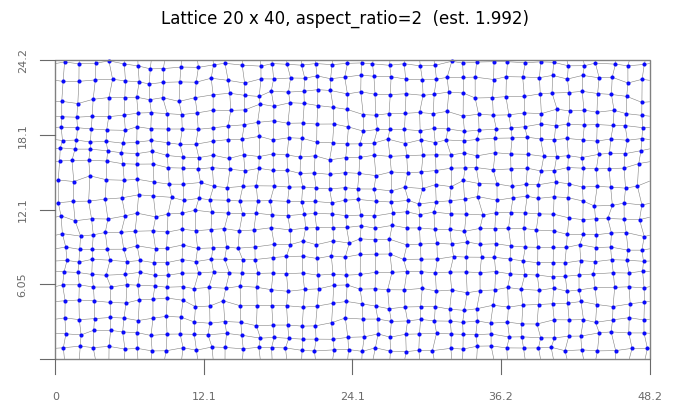

In [141]:
# ── Test: aspect_ratio = 2 (degenerate 4D group at 4λ₁) ─────────────────────
G2, D2 = graphio.get_periodic_lattice(20, 40)

result2 = find_fundamental_torus_directions(
    D2, k=15, n_eigs=30, harmonic_threshold=0.75, max_harmonic=8,
)

d0, d1 = result2["fundamental_directions"]
print(f"aspect_ratio=2  →  estimated {result2['aspect_ratio']:.4f}")
print(f"  dir0: λ={d0['lambda_mean']:.5f}  L={d0['side_length']:.2f}")
print(f"  dir1: λ={d1['lambda_mean']:.5f}  L={d1['side_length']:.2f}")
print("Skipped:", len(result2["skipped_harmonics"]))
for h in result2["skipped_harmonics"]:
    m = h["matched_to"]
    print(f"  λ≈{h['lambda_mean']:.5f}  harmonic {m['harmonic']} of dir {m['reference_direction']}  score={m['score']:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
vis.plot_embedding_with_torus_edges(
    G=G2, torus=_torus_geom_from_result(result2), ax=ax, s=4, edge_alpha=0.5)
ax.set_title(f"Lattice 20 x 40, aspect_ratio=2  (est. {result2['aspect_ratio']:.3f})")
fig.savefig(
    os.path.join(res_path, "lattice_init.png"),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08,
)


aspect_ratio=1  →  estimated 1.0000
  dir0: λ=0.06769  L=24.15
  dir1: λ=0.06769  L=24.15
Skipped: 0


Text(0.5, 1.0, 'Lattice 20 x 20,aspect_ratio=1  (est. 1.000, flatness split)')

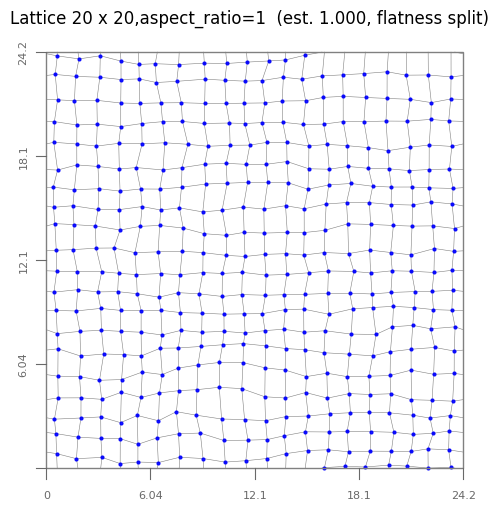

In [135]:
# ── Test: aspect_ratio = 1 (first 4D eigenspace, no prior reference) ─────────
G1, D1 = graphio.get_periodic_lattice(20, 20)

result1 = find_fundamental_torus_directions(
    D1, k=15, n_eigs=30, harmonic_threshold=0.75, max_harmonic=8,
)

d0, d1 = result1["fundamental_directions"]
print(f"\naspect_ratio=1  →  estimated {result1['aspect_ratio']:.4f}")
print(f"  dir0: λ={d0['lambda_mean']:.5f}  L={d0['side_length']:.2f}")
print(f"  dir1: λ={d1['lambda_mean']:.5f}  L={d1['side_length']:.2f}")
print("Skipped:", len(result1["skipped_harmonics"]))

init1 = torus_init_from_eigenpairs(d0["eigenvectors"], d1["eigenvectors"])


fix, ax = plt.subplots(1, 1, figsize=(5, 5))
vis.plot_embedding_with_torus_edges(
  G=G1, torus=_torus_geom_from_result(result1), ax=ax, s=4, edge_alpha=0.5)
ax.set_title(f"Lattice 20 x 20,aspect_ratio=1  (est. {result1['aspect_ratio']:.3f}, flatness split)")




aspect_ratio=1  →  estimated 3.9499
  dir0: λ=0.00431  L=95.67
  dir1: λ=0.06729  L=24.22
Skipped: 3


Text(0.5, 1.0, 'Lattice 20 x 80, aspect_ratio=4  (est. 3.950)')

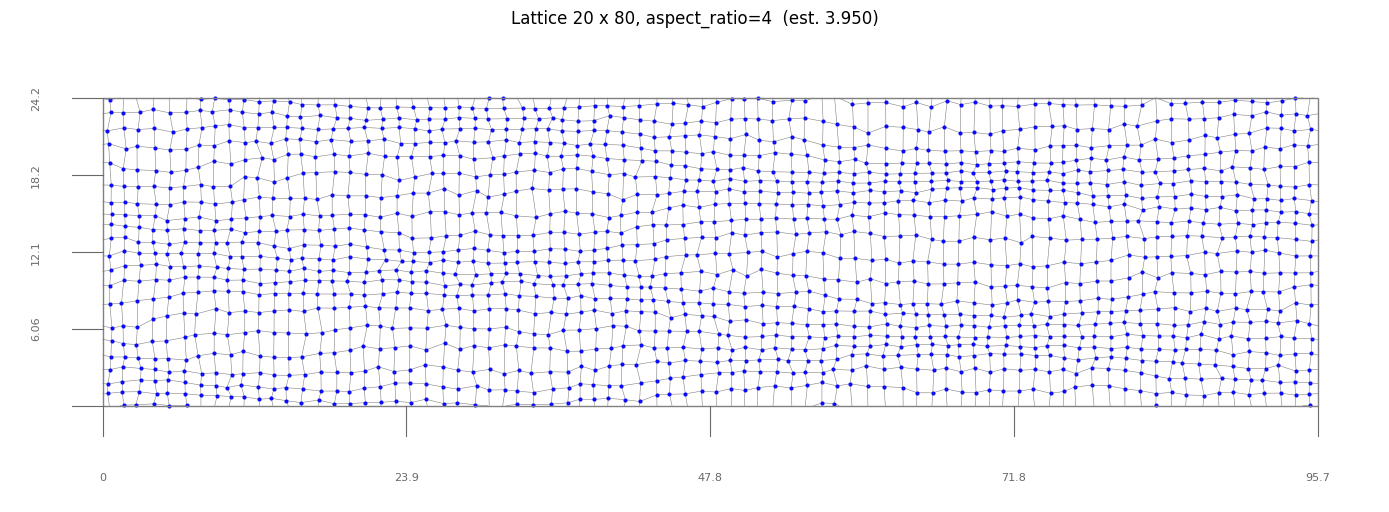

In [138]:
# test procedure on a periodic grid with aspect ratio 4

G0, D0 = graphio.get_periodic_lattice(20, 80)

result1 = find_fundamental_torus_directions(
    D0, k=15, n_eigs=30, harmonic_threshold=0.75, max_harmonic=8,
)

d0, d1 = result1["fundamental_directions"]
print(f"\naspect_ratio=1  →  estimated {result1['aspect_ratio']:.4f}")
print(f"  dir0: λ={d0['lambda_mean']:.5f}  L={d0['side_length']:.2f}")
print(f"  dir1: λ={d1['lambda_mean']:.5f}  L={d1['side_length']:.2f}")
print("Skipped:", len(result1["skipped_harmonics"]))

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
vis.plot_embedding_with_torus_edges(
    G=G0, torus=_torus_geom_from_result(result1), ax=ax, s=4, edge_alpha=0.5)
ax.set_title(f"Lattice 20 x 80, aspect_ratio=4  (est. {result1['aspect_ratio']:.3f})")


In [ ]:
# benchmark aspect ratio in more detail

In [131]:

def benchmark_periodic_lattice_aspect_ratios(
    graphio,
    pairs=None,
    n_pairs=100,
    seed=None,
    k=15,
    sigma=None,
    normalized=True,
    n_eigs=40,
    zero_tol=1e-8,
    harmonic_threshold=0.75,
    max_harmonic=10,
    verbose=True,
):
    """
    Benchmark spectral aspect-ratio estimation on periodic lattice graphs.

    Assumes:
        G, D = graphio.get_periodic_lattice(short_side, long_side)

    and that `find_fundamental_torus_directions` is already defined.

    By default, draws n_pairs random (short_side, aspect_ratio) pairs with
    short_side uniform in [5, 40] and aspect_ratio uniform in [1, 10],
    keeping only pairs where long_side = round(aspect_ratio * short_side) <= 100.

    Parameters
    ----------
    graphio : module-like object
        Must provide graphio.get_periodic_lattice(m, n).
    pairs : list of (int, float) or None
        Explicit list of (short_side, aspect_ratio) pairs to test.
        When provided, n_pairs and seed are ignored.
    n_pairs : int
        Number of random pairs to generate when pairs is None.
    seed : int or None
        Random seed for reproducibility.
    k, sigma, normalized, n_eigs, zero_tol :
        Passed to find_fundamental_torus_directions.
    harmonic_threshold, max_harmonic :
        Harmonic filtering parameters.
    verbose : bool
        Print failures and progress.

    Returns
    -------
    results : list of dict
        One entry per successful computation.
    failures : list of dict
        One entry per failed computation.
    """

    if pairs is None:
        rng = np.random.default_rng(seed=seed)
        pairs = []
        while len(pairs) < n_pairs:
            s = int(rng.integers(5, 41))       # uniform integer in [5, 40]
            r = float(rng.uniform(1.0, 10.0))  # uniform float in [1, 10]
            if int(round(r * s)) <= 100:
                pairs.append((s, r))

    results = []
    failures = []

    for s, r in pairs:
        l = int(round(r * s))

        if l < s or l > 100:
            continue

        true_ratio = l / s

        try:
            G, D = graphio.get_periodic_lattice(s, l)

            out = find_fundamental_torus_directions(
                D,
                k=k,
                sigma=sigma,
                normalized=normalized,
                n_eigs=n_eigs,
                zero_tol=zero_tol,
                harmonic_threshold=harmonic_threshold,
                max_harmonic=max_harmonic,
            )

            estimated_ratio = out["aspect_ratio"]

            results.append({
                "short_side": s,
                "long_side": l,
                "true_aspect_ratio": true_ratio,
                "estimated_aspect_ratio": estimated_ratio,
                "abs_error": abs(estimated_ratio - true_ratio),
                "rel_error": abs(estimated_ratio - true_ratio) / true_ratio,
                "eigenvalues": out["nonzero_eigenvalues"],
                "skipped_harmonics": out["skipped_harmonics"],
            })

            if verbose:
                print(
                    f"s={s:2d}, l={l:3d}, "
                    f"true={true_ratio:5.2f}, "
                    f"est={estimated_ratio:7.3f}"
                )

        except Exception as e:
            failures.append({
                "short_side": s,
                "long_side": l,
                "true_aspect_ratio": true_ratio,
                "error": repr(e),
            })

            if verbose:
                print(
                    f"FAILED: s={s}, l={l}, "
                    f"true={true_ratio:.2f}: {e}"
                )

    return results, failures


In [132]:

def plot_aspect_ratio_benchmark(results):
    """
    Plot estimated vs true aspect ratio.
    """

    true = np.array([r["true_aspect_ratio"] for r in results])
    estimated = np.array([r["estimated_aspect_ratio"] for r in results])
    short_sides = np.array([r["short_side"] for r in results])

    fig = plt.figure(figsize=(6, 5))

    sc = plt.scatter(
        true,
        estimated,
        c=short_sides,
        alpha=0.8,
    )

    plt.plot([1, 10], [1, 10], "--", label="ideal")

    plt.xlim(1, 10)
    plt.ylim(1, 10)

    plt.xlabel("True aspect ratio")
    plt.ylabel("Estimated aspect ratio")
    plt.title("Spectral flat-torus aspect ratio estimate")
    plt.colorbar(sc, label="short side length")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fig


In [133]:

results, failures = benchmark_periodic_lattice_aspect_ratios(
    graphio,
    seed=42,
    k=8,
    sigma=None,
    normalized=True,
    n_eigs=50,
    harmonic_threshold=0.75,
    max_harmonic=12,
)

s= 8, l= 40, true= 5.00, est=  4.459
s= 8, l= 15, true= 1.88, est=  1.870
s=32, l= 69, true= 2.16, est=  2.066
s=13, l= 20, true= 1.54, est=  1.521
s=29, l= 80, true= 2.76, est=  2.795
s=22, l= 53, true= 2.41, est=  2.441
s= 6, l= 43, true= 7.17, est=  6.277
s=18, l= 49, true= 2.72, est=  2.777
s= 9, l= 27, true= 3.00, est=  2.773
s=20, l= 90, true= 4.50, est=  4.416
s=13, l= 29, true= 2.23, est=  2.041
s=29, l= 81, true= 2.79, est=  2.825
s= 5, l= 35, true= 7.00, est=  5.256
s=23, l= 52, true= 2.26, est=  2.324
s=25, l= 51, true= 2.04, est=  1.989
s= 7, l= 47, true= 6.71, est=  5.716
s= 8, l= 30, true= 3.75, est=  3.467
s=25, l= 32, true= 1.28, est=  1.275
s=17, l= 50, true= 2.94, est=  2.922
s=20, l= 94, true= 4.70, est=  4.619
s=35, l= 53, true= 1.51, est=  1.457
s= 9, l= 72, true= 8.00, est=  7.461
s=19, l= 48, true= 2.53, est=  2.567
s=17, l= 31, true= 1.82, est=  1.772
s= 5, l= 38, true= 7.60, est=  5.558
s=30, l= 74, true= 2.47, est=  2.510
s=10, l= 50, true= 5.00, est=  4.736
s

/tmp/ipykernel_1378421/1561345114.py:74: RuntimeWarning: k >= N for N * N square matrix. Attempting to use scipy.linalg.eigh instead.
  evals, evecs = eigsh(L, k=n_eigs, which="SM")


s=29, l= 81, true= 2.79, est=  2.825
s=34, l= 72, true= 2.12, est=  2.031
s= 9, l= 84, true= 9.33, est=  8.532
s= 7, l= 26, true= 3.71, est=  3.269
s=28, l=100, true= 3.57, est=  3.545
s=39, l= 48, true= 1.23, est=  1.216
s=10, l= 20, true= 2.00, est=  1.929
s=27, l= 61, true= 2.26, est=  2.303
s=11, l= 91, true= 8.27, est=  7.694
s=27, l= 31, true= 1.15, est=  1.151
s=33, l= 65, true= 1.97, est=  1.962
s=14, l= 45, true= 3.21, est=  3.043
s=21, l= 66, true= 3.14, est=  3.018
s=31, l= 60, true= 1.94, est=  1.948
s= 7, l= 16, true= 2.29, est=  2.253
s=11, l= 42, true= 3.82, est=  3.658
s=34, l= 78, true= 2.29, est=  2.357
s=37, l= 92, true= 2.49, est=  2.543
s=25, l= 51, true= 2.04, est=  1.989
s=10, l= 12, true= 1.20, est=  1.210
s=30, l= 77, true= 2.57, est=  2.595
s= 6, l=  9, true= 1.50, est=  1.530
s=33, l= 46, true= 1.39, est=  1.366
s=35, l= 92, true= 2.63, est=  2.674
s=13, l= 80, true= 6.15, est=  5.893
s=39, l= 56, true= 1.44, est=  1.418
s=19, l= 83, true= 4.37, est=  4.099
s

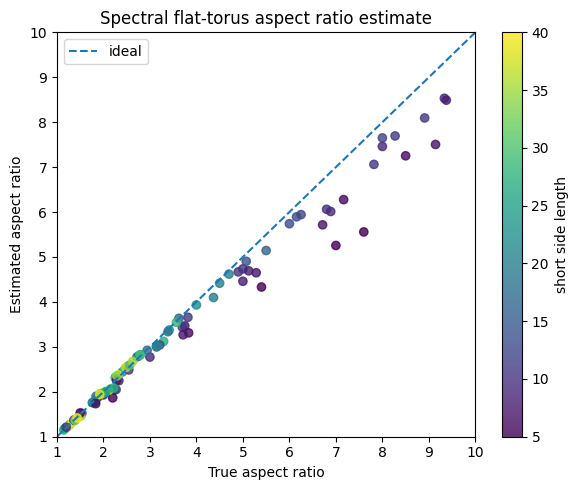

In [137]:
fig = plot_aspect_ratio_benchmark(results)
fig.savefig(os.path.join(res_path, "aspect_ratio_estimates.png"), dpi=300)